In [1]:
import os
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.initializers import HeNormal
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import cv2

dataset = "../Dataset/"
train_dir = dataset + "train"
test_dir = dataset + "test"
val_dir = dataset + "val"

# Image Data Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.7,1.3]
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Load Image Data
train_data = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=64, class_mode='categorical')
val_data = val_datagen.flow_from_directory(val_dir, target_size=(256, 256), batch_size=64, class_mode='categorical')
test_data = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=64, class_mode='categorical', shuffle=False)

2025-02-19 17:53:46.671918: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-19 17:53:46.686857: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-19 17:53:46.844744: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-19 17:53:46.962756: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739987627.096055     497 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739987627.12

Found 1470 images belonging to 21 classes.
Found 420 images belonging to 21 classes.
Found 210 images belonging to 21 classes.


In [2]:
inputs = Input(shape=(256, 256, 3))

####################################
#       Creating the CNN Model     #
####################################
# First Block
x = Conv2D(32, (5,5), activation="relu", padding="same", kernel_initializer=HeNormal())(inputs)
x = Conv2D(32, (5,5), activation="relu", padding="same", kernel_initializer=HeNormal())(x)
x = MaxPooling2D(pool_size=(2,2))(x)

# Second Block
x = Conv2D(64, (3,3), activation="relu", padding="same", kernel_initializer=HeNormal())(x)
x = MaxPooling2D(pool_size=(2,2))(x)

# Third Block
x = Conv2D(128, (3,3), activation="relu", padding="same")(x)
x = MaxPooling2D(pool_size=(2,2))(x)

# Fourth Block
x = Conv2D(256, (3,3), activation="relu", padding="same", name="last_conv")(x)
x = BatchNormalization()(x)
x = MaxPooling2D(pool_size=(2,2))(x)

# Global Pooling + Fully Connected Layers
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(21, activation="softmax")(x)  # 21 classes

cnn_model = Model(inputs=inputs, outputs=outputs)

W0000 00:00:1739987637.821155     497 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:
####################################
#       CNN Model Parameters       #
####################################
# Callbacks
early_stopping = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1)

initial_learning_rate = 0.001  
lr_scheduler = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=initial_learning_rate,
    first_decay_steps=10,  # Adjust based on total epochs
    t_mul=2.0,             # Multiplier for decay cycle length
    m_mul=0.9,             # Multiplier for LR at each restart
    alpha=0.0001           # Minimum LR
)

# Compile Model
cnn_model.compile(optimizer=Adam(learning_rate=lr_scheduler), loss="categorical_crossentropy", metrics=["accuracy"])

# Model Summary
cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 32)   │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │         2,709 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 452,213 (1.73 MB)

 Trainable params: 451,701 (1.72 MB)

 Non-trainable params: 512 (2.00 KB)

In [4]:
####################################
#       Training & Testing         #
####################################
# Train Model
epochs = 200
history = cnn_model.fit(train_data, validation_data=test_data, epochs=epochs, verbose=1)

# Evaluate Model
test_loss, test_acc = cnn_model.evaluate(test_data, verbose=1)
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# Predict on Test Data
y_pred_prob = cnn_model.predict(test_data)  # Probability outputs
y_pred = np.argmax(y_pred_prob, axis=1)       # Convert to class labels
y_true = test_data.classes                    # True labels

/home/anupam/miniconda3/envs/myenv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 143s 6s/step - accuracy: 0.0956 - loss: 3.0349 - val_accuracy: 0.0571 - val_loss: 3.1421
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 90s 4s/step - accuracy: 0.2151 - loss: 2.5841 - val_accuracy: 0.1905 - val_loss: 2.8356
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 146s 6s/step - accuracy: 0.2111 - loss: 2.4883 - val_accuracy: 0.1143 - val_loss: 2.7964
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.2524 - loss: 2.3866 - val_accuracy: 0.1333 - val_loss: 2.6945
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.3132 - loss: 2.2093 - val_accuracy: 0.2048 - val_loss: 2.5610
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 83s 4s/step - accuracy: 0.3284 - loss: 2.1168 - val_accuracy: 0.2524 - val_loss: 2.4020
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.3498 - loss: 2.0400 - val_accuracy: 0.2810 - val_loss: 2.4780
Epoch 8/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.3556 - loss: 2.0196 - val_accuracy: 0.3048 -


Classification Report:
                    precision    recall  f1-score   support

     agricultural       1.00      1.00      1.00        10
         airplane       0.90      0.90      0.90        10
  baseballdiamond       1.00      1.00      1.00        10
            beach       1.00      1.00      1.00        10
        buildings       1.00      0.90      0.95        10
        chaparral       1.00      1.00      1.00        10
 denseresidential       0.78      0.70      0.74        10
           forest       0.91      1.00      0.95        10
          freeway       1.00      0.80      0.89        10
       golfcourse       1.00      0.90      0.95        10
           harbor       1.00      1.00      1.00        10
     intersection       0.69      0.90      0.78        10
mediumresidential       0.73      0.80      0.76        10
   mobilehomepark       0.90      0.90      0.90        10
         overpass       0.90      0.90      0.90        10
       parkinglot       1.00  

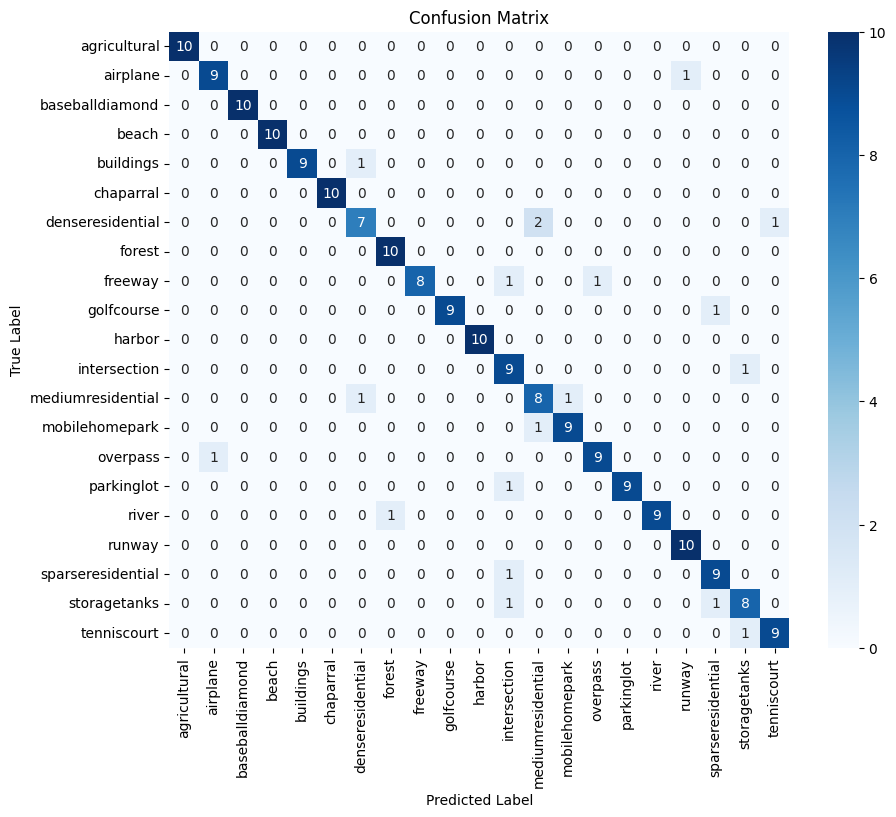

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step


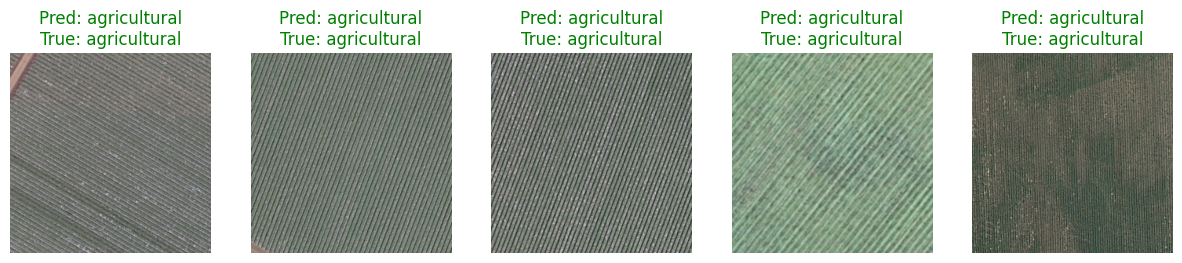

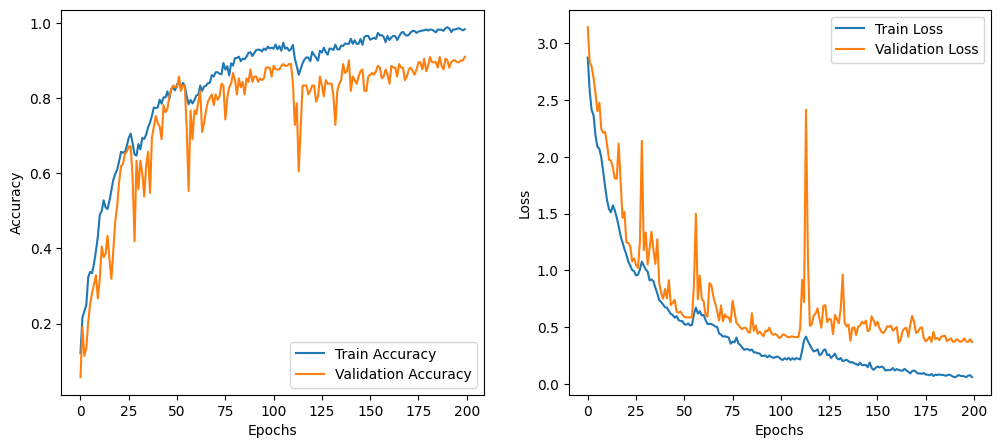

In [5]:
####################################
#       Displaying the ResultsS     #
####################################

# Print Classification Report
class_labels = list(test_data.class_indices.keys())  # Class names
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Function to Display Some Test Images with Predictions
def plot_predictions(test_data, model, num_images=5):
    test_images, test_labels = next(test_data)  # Get a batch of test images
    predictions = model.predict(test_images)

    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(test_images[i])
        pred_label = class_labels[np.argmax(predictions[i])]
        true_label = class_labels[np.argmax(test_labels[i])]
        color = "green" if pred_label == true_label else "red"
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
        plt.axis("off")
    plt.show()

# Plot sample predictions
plot_predictions(test_data, cnn_model, num_images=5)

# Plot Training Metrics
plt.figure(figsize=(12, 5))
# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [7]:
from tensorflow.keras.models import load_model
cnn_model = load_model("./cnn.h5")

/home/anupam/miniconda3/envs/myenv/lib/python3.10/site-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)


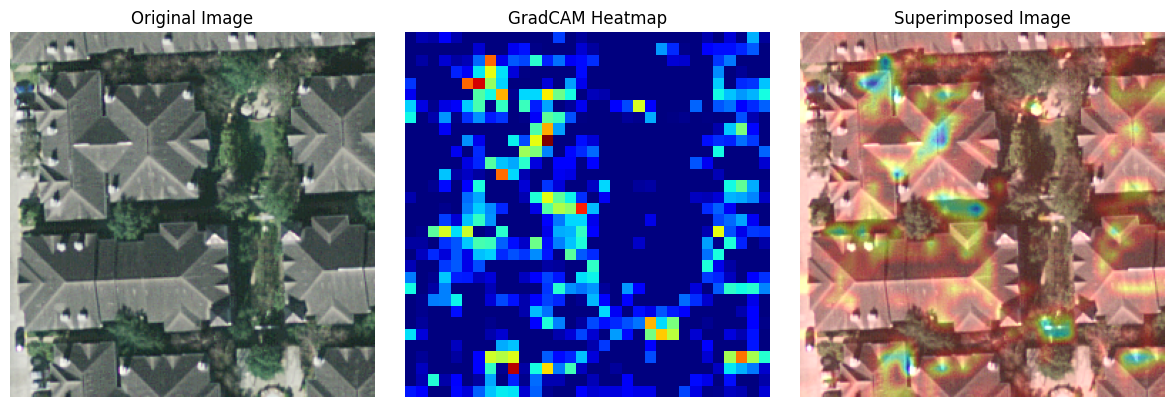

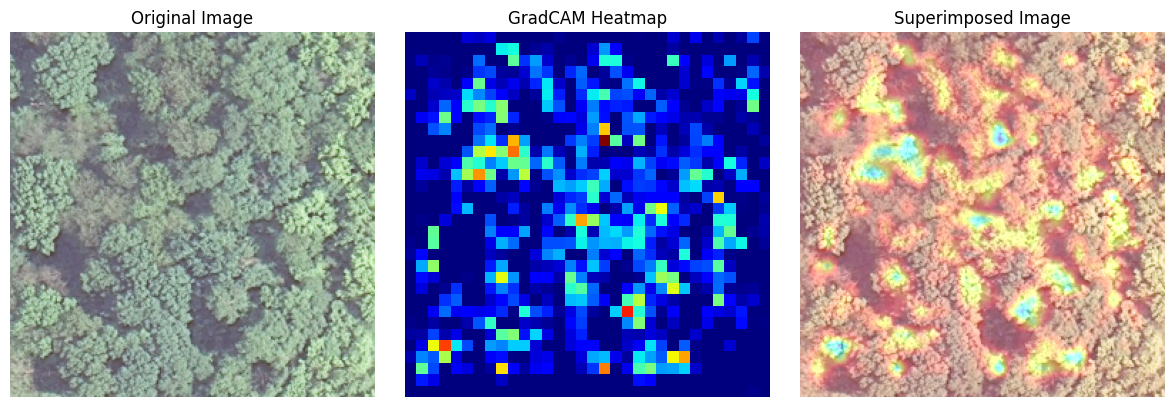

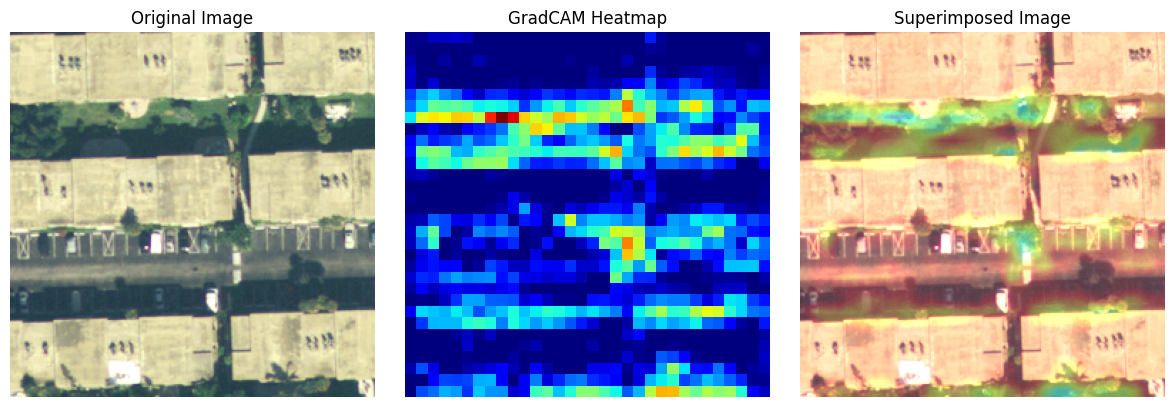

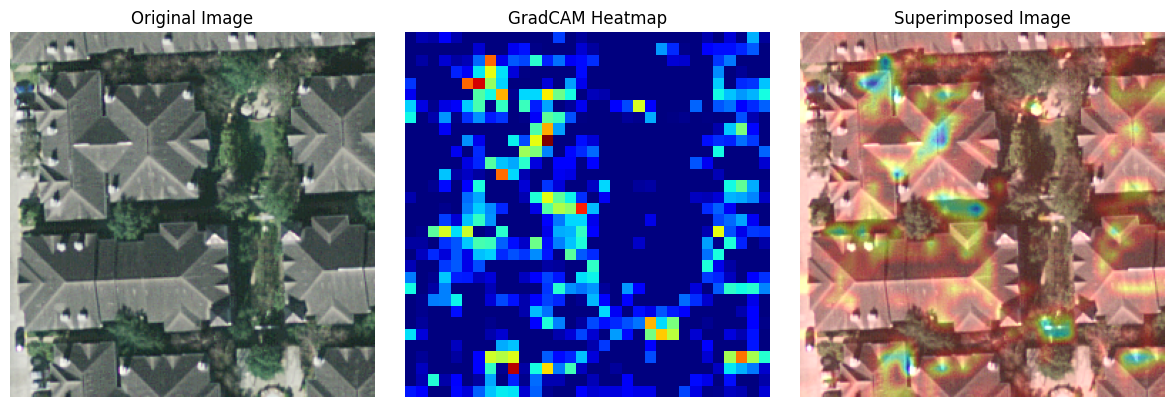

In [8]:
import cv2
def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):

    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    
    # Compute gradients of the target class w.r.t. the output feature map of the last conv layer
    grads = tape.gradient(class_channel, conv_outputs)
    # Pool the gradients over all the axes leaving out the channel dimension
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    # Weight the output feature map with the pooled gradients
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Apply ReLU to the heatmap and normalize it
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + tf.keras.backend.epsilon())
    return heatmap.numpy()

def superimpose_heatmap(img, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    # Convert the heatmap to RGB
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, colormap)
    # Superimpose the heatmap on the original image
    superimposed_img = heatmap * alpha + img
    # Ensure pixel values are between 0 and 255 and convert to uint8
    superimposed_img = np.clip(superimposed_img, 0, 255).astype("uint8")
    return superimposed_img


test_images, test_labels = next(test_data)
# Choose 2 images to visualize
num_visualizations = 4
import random
random_images = [random.randint(1,10) for _ in range(4)]
# Ensure images are in the correct scale (0-255) for visualization (they were rescaled to 0-1)
for i in random_images:
    # Prepare image for GradCAM: add batch dimension
    img = test_images[i]
    img_expanded = np.expand_dims(img, axis=0)
    
    # Generate GradCAM heatmap using the last convolutional layer named "last_conv"
    heatmap = get_gradcam_heatmap(cnn_model, img_expanded, last_conv_layer_name="last_conv")
    img_display = np.uint8(255 * img)
    
    # Superimpose the heatmap on the original image
    superimposed_img = superimpose_heatmap(img_display, heatmap, alpha=0.4)
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img_display)
    plt.title("Original Image")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("GradCAM Heatmap")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_img)
    plt.title("Superimposed Image")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()